Preprocessing

In [ ]:
import glob
import json
import pandas as pd

def preprocess_weather_jsons_colab(output_path=None, tz_local=None):
    """
    Load all .json weather files in the current working directory, clean and concatenate them.
    """
    all_dfs = []
    # glob all .json files in /content (Colab's cwd)
    for fn in glob.glob("/content/*.json"):
        city = fn.split("/")[-1].replace(".json","")
        with open(fn, 'r') as f:
            data = json.load(f)
        df = pd.json_normalize(data)
        df['city'] = city
        # convert epoch → datetime (UTC)
        df['timestamp'] = pd.to_datetime(df['time'], unit='s', utc=True)
        if tz_local:
            df['timestamp'] = df['timestamp'].dt.tz_convert(tz_local)
        df = df.drop(columns=['time'])
        df = df.sort_values('timestamp').ffill()
        all_dfs.append(df)
    weather = pd.concat(all_dfs, ignore_index=True).reset_index(drop=True)
    if output_path:
        weather.to_csv(output_path, index=False)
        print(f"Saved cleaned weather to {output_path}")
    return weather

def preprocess_electric_demand_colab(csv_filename, output_path=None, use_utc=False):
    """
    Load and clean the electricity demand CSV in Colab.
    """
    df = pd.read_csv(f"/content/{csv_filename}", parse_dates=['local_time','utc_time'])
    ts_col = 'utc_time' if use_utc else 'local_time'
    df = df.rename(columns={ts_col: 'timestamp'})
    df = df.drop(columns=[c for c in ['local_time','utc_time'] if c != ts_col])
    df['city'] = df['city'].str.lower()
    df = df.sort_values(['city','timestamp']).drop_duplicates().reset_index(drop=True)
    if output_path:
        df.to_csv(output_path, index=False)
        print(f"Saved cleaned demand to {output_path}")
    return df

# === Example usage in Colab ===

# 1. Preprocess all weather JSONs in /content
weather_df = preprocess_weather_jsons_colab(
    output_path="weather_cleaned.csv",
    tz_local=None      # or e.g. 'America/Chicago'
)

# 2. Preprocess your demand CSV (uploaded as cleaned_subregion_data.csv)
demand_df = preprocess_electric_demand_colab(
    csv_filename="cleaned_subregion_data.csv",
    output_path="demand_cleaned.csv",
    use_utc=False
)

# 3. Inspect the heads
print(weather_df.head())
print(demand_df.head())

Saved cleaned weather to weather_cleaned.csv
Saved cleaned demand to demand_cleaned.csv
  summary         icon  precipIntensity  precipProbability  temperature  \
0   Clear  clear-night              0.0                0.0        80.27   
1   Clear  clear-night              0.0                0.0        79.74   
2   Clear  clear-night              0.0                0.0        78.14   
3   Clear  clear-night              0.0                0.0        76.94   
4   Clear  clear-night              0.0                0.0        76.07   

   apparentTemperature  dewPoint  humidity  pressure  windSpeed  windGust  \
0                83.79     70.79      0.73    1017.3       3.03      3.21   
1                82.67     69.59      0.71    1017.2       2.39      2.39   
2                79.19     69.70      0.75    1017.6       1.78      1.78   
3                78.02     69.75      0.79    1017.6       0.95      1.21   
4                77.20     69.96      0.81    1017.5       1.23      1.49   

In [ ]:
weather_df

,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,pressure,windSpeed,windGust,windBearing,cloudCover,uvIndex,visibility,precipType,ozone,precipAccumulation,city,timestamp
0,Clear,clear-night,0.0000,0.00,80.27,83.79,70.79,0.73,1017.3,3.03,3.21,238.0,0.12,0.0,9.964,NaN,NaN,NaN,philadelphia,2018-07-02 04:00:00+00:00
1,Clear,clear-night,0.0000,0.00,79.74,82.67,69.59,0.71,1017.2,2.39,2.39,226.0,0.05,0.0,9.705,NaN,NaN,NaN,philadelphia,2018-07-02 05:00:00+00:00
2,Clear,clear-night,0.0000,0.00,78.14,79.19,69.70,0.75,1017.6,1.78,1.78,226.0,0.20,0.0,9.553,NaN,NaN,NaN,philadelphia,2018-07-02 06:00:00+00:00
3,Clear,clear-night,0.0000,0.00,76.94,78.02,69.75,0.79,1017.6,0.95,1.21,192.0,0.12,0.0,9.401,NaN,NaN,NaN,philadelphia,2018-07-02 07:00:00+00:00
4,Clear,clear-night,0.0000,0.00,76.07,77.20,69.96,0.81,1017.5,1.23,1.49,214.0,0.05,0.0,8.918,NaN,NaN,NaN,philadelphia,2018-07-02 08:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165735,Partly Cloudy,partly-cloudy-day,0.0204,0.25,52.91,52.91,45.30,0.75,1015.1,3.79,4.41,39.0,0.34,0.0,10.000,rain,391.2,0.0041,seattle,2020-05-22 02:00:00+00:00
165736,Partly Cloudy,partly-cloudy-day,0.0106,0.23,52.19,52.19,45.58,0.78,1015.3,2.94,3.90,97.0,0.45,0.0,10.000,rain,389.0,0.0041,seattle,2020-05-22 03:00:00+00:00
165737,Partly Cloudy,partly-cloudy-night,0.0058,0.19,51.22,51.22,46.04,0.82,1015.5,3.38,5.00,144.0,0.40,0.0,10.000,rain,386.0,0.0041,seattle,2020-05-22 04:00:00+00:00
165738,Partly Cloudy,partly-cloudy-night,0.0023,0.12,50.07,50.07,46.23,0.87,1015.9,3.76,5.87,148.0,0.38,0.0,9.881,rain,382.2,0.0041,seattle,2020-05-22 05:00:00+00:00


In [ ]:
demand_df

,company,region,demand,timestamp,city
0,ERCO,NCEN,NaN,2018-07-01 01:00:00,dallas
1,ERCO,NCEN,NaN,2018-07-01 02:00:00,dallas
2,ERCO,NCEN,NaN,2018-07-01 03:00:00,dallas
3,ERCO,NCEN,NaN,2018-07-01 04:00:00,dallas
4,ERCO,NCEN,NaN,2018-07-01 05:00:00,dallas
...,...,...,...,...,...
132278,CISO,PGAE,11578.0,2020-05-19 20:00:00,san jose
132279,CISO,PGAE,11782.0,2020-05-19 21:00:00,san jose
132280,CISO,PGAE,11592.0,2020-05-19 22:00:00,san jose
132281,CISO,PGAE,11083.0,2020-05-19 23:00:00,san jose


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# 1) load cleaned CSVs
weather = pd.read_csv('/content/weather_cleaned.csv', parse_dates=['timestamp'])
demand  = pd.read_csv('/content/demand_cleaned.csv',  parse_dates=['timestamp'])

# 2) select only the needed weather columns
weather = weather[['timestamp','city','temperature','humidity','windSpeed']]

# 3) drop rows in demand with NaN demand
demand = demand.dropna(subset=['demand']).reset_index(drop=True)

# 4) Missing‑value check & simple handling
#    (weather was forward‑filled earlier, but double‑check)
print("weather NA per column:\n", weather.isna().sum())
print("demand NA per column:\n",  demand.isna().sum())
# if any remain, drop them:
weather = weather.dropna().reset_index(drop=True)

# 5) FEATURE ENGINEERING: time features & season
def add_time_feats(df):
    df['hour']       = df['timestamp'].dt.hour
    df['dayofweek']  = df['timestamp'].dt.dayofweek      # Mon=0…Sun=6
    df['month']      = df['timestamp'].dt.month
    # map month → season
    df['season'] = df['month'].map({
        12:'winter',1:'winter',2:'winter',
        3:'spring',4:'spring',5:'spring',
        6:'summer',7:'summer',8:'summer',
        9:'fall',10:'fall',11:'fall'
    })
    return df

weather = add_time_feats(weather)
demand  = add_time_feats(demand)

# 6) SCALING (StandardScaler)
sc_w = StandardScaler()
weather[['temp_s','hum_s','wind_s']] = sc_w.fit_transform(
    weather[['temperature','humidity','windSpeed']]
)

sc_d = StandardScaler()
demand[['demand_s']] = sc_d.fit_transform(demand[['demand']])

# 7) DAILY & WEEKLY AGGREGATION
#   — weather daily stats
weather.set_index('timestamp', inplace=True)
weather_daily = (
    weather
      .groupby(['city', pd.Grouper(freq='D')])
      [['temperature','humidity','windSpeed']]
      .agg(['mean','min','max','std'])
)
weather_weekly = (
    weather
      .groupby(['city', pd.Grouper(freq='W')])
      [['temperature','humidity','windSpeed']]
      .agg(['mean','min','max','std'])
)
weather.reset_index(inplace=True)

#   — demand daily stats
demand.set_index('timestamp', inplace=True)
demand_daily = (
    demand
      .groupby(['city', pd.Grouper(freq='D')])['demand']
      .agg(['sum','mean','max','min','std'])
)
demand_weekly = (
    demand
      .groupby(['city', pd.Grouper(freq='W')])['demand']
      .agg(['sum','mean','max','min','std'])
)
demand.reset_index(inplace=True)

# 8) ANOMALY DETECTION
#    a) z‑score method on demand
demand['demand_z'] = (demand['demand'] - demand['demand'].mean())/demand['demand'].std()
anom_z = demand[np.abs(demand['demand_z']) > 3]
print(f"Z‑score anomalies in demand: {len(anom_z)} rows")

#    b) IsolationForest on weather
iso_w = IsolationForest(contamination=0.01, random_state=42)
weather['anomaly_w'] = iso_w.fit_predict(weather[['temperature','humidity','windSpeed']])
anom_w = weather[weather['anomaly_w']==-1]
print(f"IForest anomalies in weather: {len(anom_w)} rows")

# DECISION: drop those anomalies (or inspect manually)
weather_clean = weather[weather['anomaly_w'] == 1].drop(columns=['anomaly_w'])
demand_clean  = demand[ np.abs(demand['demand_z']) <= 3].drop(columns=['demand_z'])

# now weather_clean & demand_clean are ready for merge
print("Final shapes:", weather_clean.shape, demand_clean.shape)


weather NA per column:
 timestamp      0
city           0
temperature    0
humidity       0
windSpeed      0
dtype: int64
demand NA per column:
 company      0
region       0
demand       0
timestamp    0
city         0
dtype: int64
Z‑score anomalies in demand: 527 rows
IForest anomalies in weather: 1658 rows
Final shapes: (164082, 12) (105789, 10)


In [ ]:
# weather_clean and demand_clean from your last run

weather_clean.to_csv('/content/weather_prepared.csv', index=False)
demand_clean.to_csv('/content/demand_prepared.csv', index=False)

print("Saved:\n - /content/weather_prepared.csv\n - /content/demand_prepared.csv")

Saved:
 - /content/weather_prepared.csv
 - /content/demand_prepared.csv


In [ ]:
print("Weather (prepared) summary:")
print(weather_clean[['temperature','humidity','windSpeed']].describe())

print("\nDemand (prepared) summary:")
print(demand_clean['demand'].describe())

Weather (prepared) summary:
         temperature       humidity      windSpeed
count  164082.000000  164082.000000  164082.000000
mean       63.108612       0.655575       5.773968
std        15.581158       0.216933       3.314681
min         3.580000       0.000000       0.000000
25%        52.120000       0.510000       3.210000
50%        62.690000       0.690000       5.020000
75%        74.320000       0.830000       7.720000
max       112.770000       1.000000      21.900000

Demand (prepared) summary:
count    105789.000000
mean       7908.712730
std        4277.782444
min           0.000000
25%        4400.000000
50%        7684.000000
75%       11029.000000
max       21140.000000
Name: demand, dtype: float64


Merging

In [ ]:
import pandas as pd

# -- Step 1: Load pre‑processed CSVs (weather has tz, demand is naive) --
weather = pd.read_csv('/content/weather_prepared.csv', parse_dates=['timestamp'])
demand  = pd.read_csv('/content/demand_prepared.csv',  parse_dates=['timestamp'])

# -- Step 2: Align timestamp dtypes: strip timezone from weather --
weather['timestamp'] = weather['timestamp'].dt.tz_localize(None)

# (Alternative: to make demand UTC-aware instead, uncomment below)
# demand['timestamp'] = demand['timestamp'].dt.tz_localize('UTC')

# -- Step 3: Merge on city & timestamp --
merged = pd.merge(
    demand,
    weather,
    on=['city', 'timestamp'],
    how='inner',             # keep only matching rows
    validate='many_to_one'    # each weather row matches at most one demand row
)

# -- Step 4: Sort, reset index, and sanity-check --
merged = merged.sort_values(['city', 'timestamp']).reset_index(drop=True)
print(f"Merged shape: {merged.shape}")
print("Missing values per column after merge:\n", merged.isna().sum())

# -- Step 5: Save to disk for modeling --
out_path = '/content/merged_dataset.csv'
merged.to_csv(out_path, index=False)
print(f"Saved merged dataset to {out_path}")

# -- Step 6: Preview first few rows --
print(merged.head(10))


Merged shape: (63540, 20)
Missing values per column after merge:
 timestamp      0
company        0
region         0
demand         0
city           0
hour_x         0
dayofweek_x    0
month_x        0
season_x       0
demand_s       0
temperature    0
humidity       0
windSpeed      0
hour_y         0
dayofweek_y    0
month_y        0
season_y       0
temp_s         0
hum_s          0
wind_s         0
dtype: int64
Saved merged dataset to /content/merged_dataset.csv
            timestamp company region   demand    city  hour_x  dayofweek_x  \
0 2019-05-27 01:00:00    ERCO   NCEN  12432.0  dallas       1            0   
1 2019-05-27 02:00:00    ERCO   NCEN  11662.0  dallas       2            0   
2 2019-05-27 03:00:00    ERCO   NCEN  11164.0  dallas       3            0   
3 2019-05-27 04:00:00    ERCO   NCEN  10768.0  dallas       4            0   
4 2019-05-27 05:00:00    ERCO   NCEN  10565.0  dallas       5            0   
5 2019-05-27 06:00:00    ERCO   NCEN  10587.0  dallas       6

Dropping duplicate columns as its noise for clustering

In [5]:
import pandas as pd

# Load the merged dataset
merged_path = "merged_dataset.csv"
merged = pd.read_csv(merged_path)

# Drop the weather-derived time features
merged.drop(columns=['hour_y', 'dayofweek_y', 'month_y', 'season_y'], inplace=True)

# Rename the demand-derived time features
merged.rename(columns={
    'hour_x': 'hour',
    'dayofweek_x': 'dayofweek',
    'month_x': 'month',
    'season_x': 'season'
}, inplace=True)

# Display the first few rows to confirm changes
merged.head()


,timestamp,company,region,demand,city,hour,dayofweek,month,season,demand_s,temperature,humidity,windSpeed,temp_s,hum_s,wind_s
0,2019-05-27 01:00:00,ERCO,NCEN,12432.0,dallas,1,0,5,spring,1.014406,84.66,0.58,10.83,1.360783,-0.335070,1.434568
1,2019-05-27 02:00:00,ERCO,NCEN,11662.0,dallas,2,0,5,spring,0.838929,82.19,0.64,10.31,1.204533,-0.060927,1.284558
2,2019-05-27 03:00:00,ERCO,NCEN,11164.0,dallas,3,0,5,spring,0.725439,80.25,0.70,10.01,1.081810,0.213216,1.198014
3,2019-05-27 04:00:00,ERCO,NCEN,10768.0,dallas,4,0,5,spring,0.635194,79.52,0.72,10.92,1.035631,0.304597,1.460531
4,2019-05-27 05:00:00,ERCO,NCEN,10565.0,dallas,5,0,5,spring,0.588932,78.87,0.74,10.65,0.994513,0.395978,1.382642


Clustering

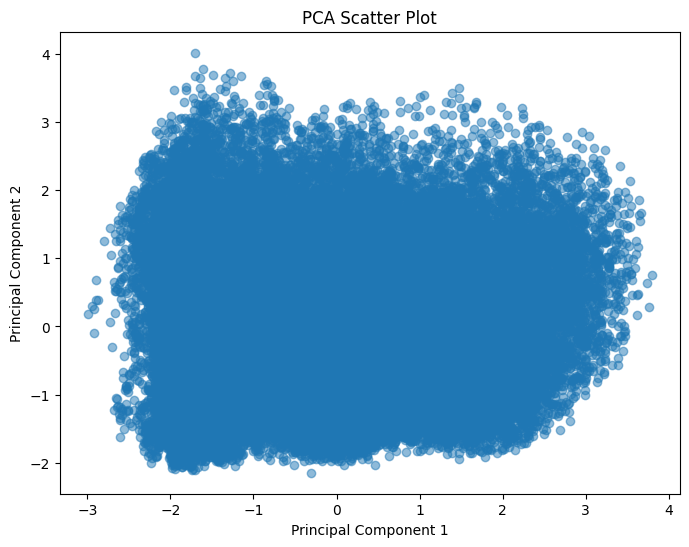

PCA Explained Variance Ratio: [0.40442669 0.27490138]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage # Import linkage here
import warnings
warnings.filterwarnings('ignore')

# Cell 2: Data Preparation
# Use merged DataFrame
features = ['demand_s', 'temp_s', 'hum_s', 'wind_s']
X = merged[features]

# Cell 3: Dimensionality Reduction - PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA Scatter Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('pca_plot.png')
plt.show()
plt.close()

# Explained variance
print(f'PCA Explained Variance Ratio: {pca.explained_variance_ratio_}')

K-Means Clustering - Elbow Method

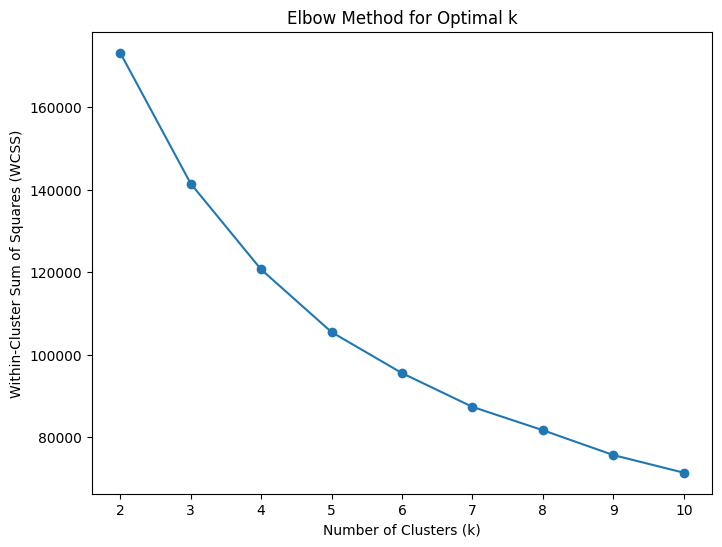

In [7]:
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.savefig('elbow_plot.png')
plt.show()
plt.close()

using k=4

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

DBSCAN Clustering

In [10]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

Hierarchical Clustering - Dendrogram

Sampling 1000 rows for hierarchical clustering to avoid memory issues.


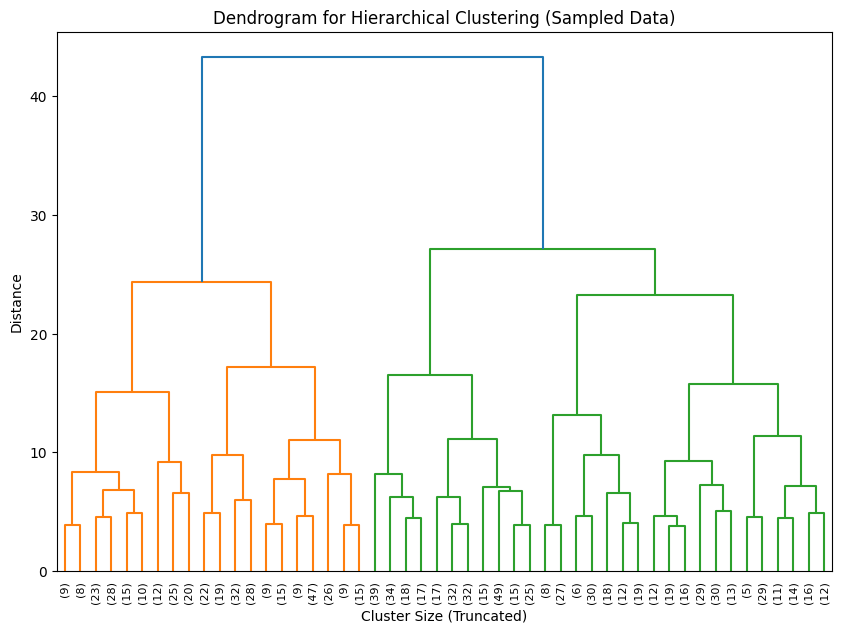

In [11]:

# Cell 7: Hierarchical Clustering - Dendrogram (Optimized)
# Sample the data to reduce memory usage (e.g., 1000 rows)
sample_size = min(1000, len(X))  # Use at most 1000 rows, or less if dataset is smaller
if sample_size < len(X):
    print(f"Sampling {sample_size} rows for hierarchical clustering to avoid memory issues.")
    sample_idx = np.random.choice(X.index, size=sample_size, replace=False)
    X_sample = X.loc[sample_idx]
else:
    X_sample = X

# Generate linkage matrix on sampled data
Z = linkage(X_sample, method='ward')

# Plot Dendrogram with truncation to avoid overcrowding
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='lastp', p=50)  # Show only the last 50 merged clusters
plt.title('Dendrogram for Hierarchical Clustering (Sampled Data)')
plt.xlabel('Cluster Size (Truncated)')
plt.ylabel('Distance')
plt.savefig('dendrogram.png')
plt.show()
plt.close()

Hierarchical Clustering - Apply with 4 clusters (Sampled Data)

In [12]:
sample_size = min(1000, len(X))  # Use at most 1000 rows, or less if dataset is smaller
if sample_size < len(X):
    print(f"Sampling {sample_size} rows for AgglomerativeClustering to avoid memory issues.")
    sample_idx = np.random.choice(X.index, size=sample_size, replace=False)
    X_sample = X.loc[sample_idx]
else:
    X_sample = X
    sample_idx = X.index

# Apply AgglomerativeClustering on sampled data
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels_sample = hierarchical.fit_predict(X_sample)

# Map sampled labels back to the full dataset (assign -1 to unsampled points)
hierarchical_labels = np.full(len(X), -1)  # Initialize with -1 (unclustered)
hierarchical_labels[sample_idx] = hierarchical_labels_sample

Sampling 1000 rows for AgglomerativeClustering to avoid memory issues.


Evaluation - Silhouette Scores (Optimized with Sampling)

In [13]:
# Sample the data for silhouette score computation (use a new sample for consistency)
sample_size_eval = min(1000, len(X))  # Use at most 1000 rows
if sample_size_eval < len(X):
    print(f"Sampling {sample_size_eval} rows for silhouette score computation to reduce runtime.")
    sample_idx_eval = np.random.choice(X.index, size=sample_size_eval, replace=False)
    X_sample_eval = X.loc[sample_idx_eval]
    kmeans_labels_sample = kmeans_labels[sample_idx_eval]
    dbscan_labels_sample = dbscan_labels[sample_idx_eval]
    hierarchical_labels_sample = hierarchical_labels[sample_idx_eval]
else:
    X_sample_eval = X
    kmeans_labels_sample = kmeans_labels
    dbscan_labels_sample = dbscan_labels
    hierarchical_labels_sample = hierarchical_labels

# Compute silhouette scores on sampled data
kmeans_silhouette = silhouette_score(X_sample_eval, kmeans_labels_sample)
dbscan_silhouette = silhouette_score(X_sample_eval, dbscan_labels_sample) if len(set(dbscan_labels_sample)) > 1 else -1
hierarchical_silhouette = silhouette_score(X_sample_eval, hierarchical_labels_sample) if len(set(hierarchical_labels_sample)) > 1 else -1

print(f'Silhouette Scores (on sampled data):')
print(f'K-Means: {kmeans_silhouette:.3f}')
print(f'DBSCAN: {dbscan_silhouette:.3f}')
print(f'Hierarchical: {hierarchical_silhouette:.3f}')

Sampling 1000 rows for silhouette score computation to reduce runtime.
Silhouette Scores (on sampled data):
K-Means: 0.237
DBSCAN: 0.166
Hierarchical: -0.243


Evaluation - Cluster Stability (K-Means)

In [14]:
from sklearn.metrics import adjusted_rand_score  # Add this import
ari_scores = []
for _ in range(10):
    sample_idx = np.random.choice(X.index, size=int(0.8 * len(X)), replace=False)
    X_sample = X.loc[sample_idx]
    kmeans_sample = KMeans(n_clusters=4, random_state=42)
    labels_sample = kmeans_sample.fit_predict(X_sample)
    labels_full = kmeans_labels[sample_idx]
    ari = adjusted_rand_score(labels_full, labels_sample)
    ari_scores.append(ari)
print(f'K-Means Cluster Stability (Mean ARI): {np.mean(ari_scores):.3f}')

K-Means Cluster Stability (Mean ARI): 0.793


Visualization - K-Means Clusters on PCA

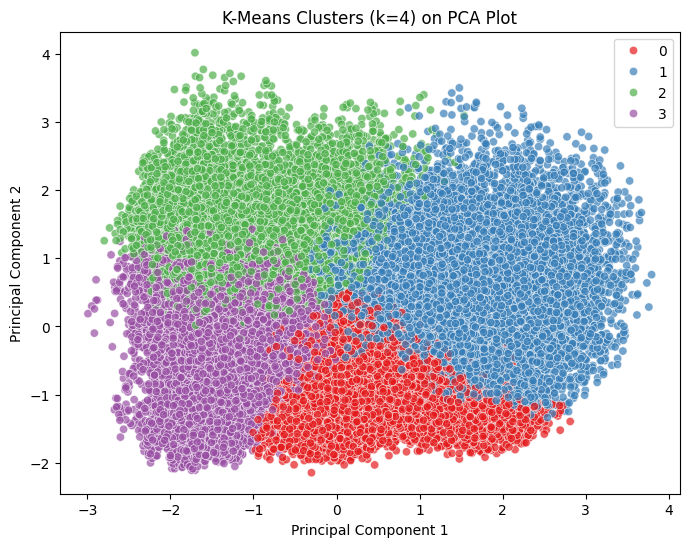

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='Set1', alpha=0.7)
plt.title('K-Means Clusters (k=4) on PCA Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('kmeans_pca_plot.png')
plt.show()
plt.close()

Interpretation - Characterize Clusters

In [16]:
# Cell 12: Interpretation - Characterize Clusters
merged['Cluster'] = kmeans_labels
numeric_features = ['demand_s', 'temp_s', 'hum_s', 'wind_s', 'hour']
cluster_summary_numeric = merged.groupby('Cluster')[numeric_features].mean()
cluster_summary_season = merged.groupby('Cluster')['season'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')

print('\nCluster Summary (Numeric Means):')
print(cluster_summary_numeric)
print('\nCluster Summary (Season Mode):')
print(cluster_summary_season)

# Interpretation of clusters
print('\nCluster Characterization:')
for cluster in cluster_summary_numeric.index:
    demand = cluster_summary_numeric.loc[cluster, 'demand_s']
    temp = cluster_summary_numeric.loc[cluster, 'temp_s']
    hum = cluster_summary_numeric.loc[cluster, 'hum_s']
    wind = cluster_summary_numeric.loc[cluster, 'wind_s']
    hour = cluster_summary_numeric.loc[cluster, 'hour']
    season = cluster_summary_season.loc[cluster]

    demand_desc = "High" if demand > 0.5 else "Moderate" if demand > 0 else "Low" if demand > -0.5 else "Very Low"
    temp_desc = "Hot" if temp > 0.5 else "Mild" if temp > -0.5 else "Cool" if temp > -1 else "Very Cold"
    time_desc = "Morning" if 6 <= hour < 12 else "Late Morning" if 9 <= hour < 11 else "Midday" if 11 <= hour < 15 else "Afternoon" if 15 <= hour < 18 else "Night"
    wind_desc = "High" if wind > 0.5 else "Moderate" if wind > -0.5 else "Low"
    hum_desc = "High" if hum > 0.5 else "Neutral" if hum > -0.5 else "Low"

    print(f"Cluster {cluster}: {demand_desc}-Demand {temp_desc} {time_desc} with {hum_desc} Humidity and {wind_desc} Wind ({season})")

# Save cluster assignments
merged.to_csv('clustered_data.csv', index=False)


Cluster Summary (Numeric Means):
         demand_s    temp_s     hum_s    wind_s       hour
Cluster                                                   
0        0.413536  0.142188  0.679347 -0.460334   9.704518
1        0.986971  0.887287 -0.797660  0.150248  13.963408
2       -0.353813 -0.526153  0.025569  1.604362  12.670984
3       -0.650552 -1.280362  0.071141 -0.171183  10.369104

Cluster Summary (Season Mode):
Cluster
0    summer
1    summer
2    spring
3    winter
Name: season, dtype: object

Cluster Characterization:
Cluster 0: Moderate-Demand Mild Morning with High Humidity and Moderate Wind (summer)
Cluster 1: High-Demand Hot Midday with Low Humidity and Moderate Wind (summer)
Cluster 2: Low-Demand Cool Midday with Neutral Humidity and High Wind (spring)
Cluster 3: Very Low-Demand Very Cold Morning with Neutral Humidity and Moderate Wind (winter)


Visualization - DBSCAN Clusters on PCA

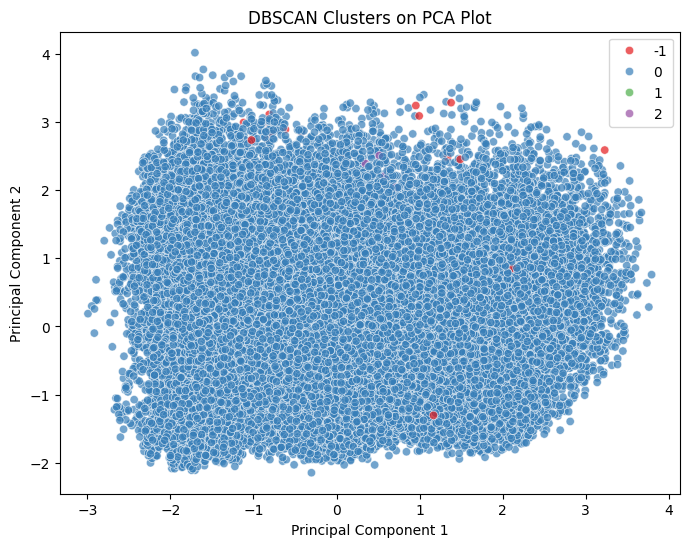

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='Set1', alpha=0.7)
plt.title('DBSCAN Clusters on PCA Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('dbscan_pca_plot.png')
plt.show()
plt.close()

Cell 14: Predictive Modeling
Forecasting Horizon (e.g., 24 hours ahead)

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the merged data with timestamp
merged = pd.read_csv('clustered_data.csv')
merged['timestamp'] = pd.to_datetime(merged['timestamp'])

# Verify timestamp is present
if 'timestamp' not in merged.columns:
    raise KeyError("timestamp column not found in merged DataFrame after loading.")

# Sort and create 24-hour lagged demand target
merged = merged.sort_values('timestamp')
merged['demand_next_24h'] = merged['demand'].shift(-24)
merged = merged.dropna()

# Encode categorical 'season' and convert to numeric (float32)
season_encoded = pd.get_dummies(merged['season'], prefix='season', dtype=np.float32)
merged = pd.concat([merged, season_encoded], axis=1).drop(columns=['season'])

# Features including Cluster
features = ['temperature', 'humidity', 'windSpeed', 'hour', 'Cluster'] + [col for col in season_encoded.columns]

# Create deduplicated dataset for all models
merged_arima = merged.copy()
merged_arima = merged_arima.set_index('timestamp')
merged_arima.index = pd.to_datetime(merged_arima.index)
duplicate_timestamps = merged_arima.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicate_timestamps}")

# Aggregate duplicates, ensuring all features are included
# Define aggregation for each column explicitly
agg_dict = {col: 'mean' for col in features + ['demand', 'demand_next_24h']}
merged_arima = merged_arima.groupby(merged_arima.index).agg(agg_dict).reset_index()
print(f"Data size after aggregating duplicates for ARIMA: {len(merged_arima)} rows")

# Prepare X and y from deduplicated data
X = merged_arima[features]
y = merged_arima['demand_next_24h']

# Convert all columns in X to float32 to ensure uniform numeric dtype
X = X.astype(np.float32)
y = y.astype(np.float32)

# Diagnostic checks for X
print("Dtypes of X columns:")
print(X.dtypes)
print("\nCheck for NaN values in X:")
print(X.isnull().sum())
print(f"Dataset size: {len(merged_arima)} rows")
print(f"Features: {features}")
print("\nCluster value counts:")
print(merged_arima['Cluster'].value_counts())
print("\nCheck for NaN values in y:")
print(y.isnull().sum())

# Save with timestamp as a column
merged_arima.to_csv('clustered_data_deduplicated.csv', index=False)
print("Updated deduplicated merged DataFrame saved with timestamp column.")

Number of duplicate timestamps: 47014
Data size after aggregating duplicates for ARIMA: 16502 rows
Dtypes of X columns:
temperature      float32
humidity         float32
windSpeed        float32
hour             float32
Cluster          float32
season_fall      float32
season_spring    float32
season_summer    float32
season_winter    float32
dtype: object

Check for NaN values in X:
temperature      0
humidity         0
windSpeed        0
hour             0
Cluster          0
season_fall      0
season_spring    0
season_summer    0
season_winter    0
dtype: int64
Dataset size: 16502 rows
Features: ['temperature', 'humidity', 'windSpeed', 'hour', 'Cluster', 'season_fall', 'season_spring', 'season_summer', 'season_winter']

Cluster value counts:
Cluster
2.000000    2346
1.000000    1944
1.200000    1358
0.000000    1351
1.666667    1228
1.400000    1133
1.600000     923
2.333333     779
1.333333     662
1.800000     648
0.500000     547
0.200000     514
0.800000     485
0.600000     413

Downloading clustered data locally

In [ ]:


# Save to CSV
merged.to_csv('clustered_data.csv', index=False)



NameError: name 'files' is not defined

Model Selection

Cell 15: Model Initialization

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import pandas as pd

# Print TensorFlow version to confirm
print(f"TensorFlow version: {tf.__version__}")

# Verify timestamp is present
print("Current columns in merged_arima:", merged_arima.columns.tolist())

# ARIMA (using aggregated data with DatetimeIndex)
merged_arima_indexed = merged_arima.set_index('timestamp')
arima_model = ARIMA(merged_arima_indexed['demand'], order=(5, 1, 0)).fit()

# Linear Regression
lr_model = LinearRegression()

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# LSTM (reshape for 3D input: [samples, timesteps, features] with explicit dtype)
X_lstm = np.array(X, dtype=np.float32).reshape((X.shape[0], 1, X.shape[1]))
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

print("Models initialized.")

TensorFlow version: 2.19.0
Current columns in merged_arima: ['timestamp', 'temperature', 'humidity', 'windSpeed', 'hour', 'Cluster', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'demand', 'demand_next_24h']
Models initialized.


Cell 16: Data Split and Model Training

In [22]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np

# Verify original data lengths
print(f"Length of X: {len(X)}, Length of y: {len(y)}")
print(f"Length of merged_arima: {len(merged_arima)}")

# Date-based split (80% train, 20% test) using X and y lengths
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert X_train and X_test to NumPy arrays with float32 before splitting
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

# Convert y_train and y_test to float32 for consistency
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Verify split lengths
print(f"Length of X_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"Length of X_test: {len(X_test)}, y_test: {len(y_test)}")

# Check if lengths match expectations
if len(X_train) + len(X_test) != len(X) or len(y_train) + len(y_test) != len(y):
    print("Warning: Split lengths do not sum to original length. Check data alignment!")
else:
    print("Split lengths are consistent with original data.")

# Create polynomial features for test set
X_poly_test = poly.transform(X_test)

# LSTM reshaping for train and test with explicit dtype
X_lstm_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_lstm_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_lstm = np.array(y, dtype=np.float32).reshape((y.shape[0], 1, 1))  # Reshape y for LSTM

# Verify dtype of X_lstm_test
print("Dtype of X_lstm_test:", X_lstm_test.dtype)

# Time Series Cross-Validation for merged_arima data
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search for Random Forest
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
print(f"Best RF params: {grid_search.best_params_}")

# Train other models
lr_model.fit(X_train, y_train)
poly_model.fit(X_poly[:train_size], y_train)
xgb_model.fit(X_train, y_train)
lstm_model.fit(X_lstm_train, y_lstm[:train_size], epochs=10, batch_size=32, verbose=1)

print("Models trained.")

Length of X: 16502, Length of y: 16502
Length of merged_arima: 16502
Length of X_train: 13201, y_train: 13201
Length of X_test: 3301, y_test: 3301
Split lengths are consistent with original data.
Dtype of X_lstm_test: float32
Best RF params: {'max_depth': 10, 'n_estimators': 200}
Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 78690368.0000
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 65960904.0000
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 42839084.0000
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22675738.0000
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10549774.0000
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6735633.5000
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5962417.0000
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5817846.5000
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5764831.0000
Epoch 10/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

Cell 17 Evaluation Metrics

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predictions for ML models
y_pred_lr = lr_model.predict(X_test)
y_pred_poly = poly_model.predict(X_poly_test)
y_pred_rf = grid_search.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_lstm_test).flatten()

# ARIMA prediction (using deduplicated data)
train_size_arima = int(0.8 * len(merged_arima))
arima_test_start = merged_arima['timestamp'].iloc[train_size_arima]
arima_test_end = merged_arima['timestamp'].iloc[-1]
y_pred_arima = arima_model.predict(start=arima_test_start, end=arima_test_end, dynamic=False)

# Align ARIMA predictions with y_test (map merged_arima timestamps to original test set)
merged_arima_indexed = merged_arima.set_index('timestamp')
y_test_arima = merged_arima_indexed.loc[arima_test_start:arima_test_end]['demand'].values

# Debug lengths
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_test_arima: {len(y_test_arima)}")
print(f"Length of y_pred_arima: {len(y_pred_arima)}")

# Custom MAPE function (handle division by zero and ensure mask matches truncated arrays)
def calculate_mape(y_true, y_pred):
    min_len = min(len(y_true), len(y_pred))
    y_true = np.asarray(y_true[:min_len], dtype=np.float32)
    y_pred = np.asarray(y_pred[:min_len], dtype=np.float32)
    print(f"Length of y_true in MAPE: {len(y_true)}")
    print(f"Length of y_pred in MAPE: {len(y_pred)}")
    mask = y_true != 0
    print(f"Length of mask: {mask.size}")
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Metrics for all models
metrics = {}
for name, y_pred in [('Linear', y_pred_lr), ('Polynomial', y_pred_poly), ('Random Forest', y_pred_rf),
                     ('XGBoost', y_pred_xgb), ('LSTM', y_pred_lstm), ('ARIMA', y_pred_arima)]:
    if name == 'ARIMA':
        y_true = y_test_arima
    else:
        y_true = y_test
    metrics[name] = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': calculate_mape(y_true, y_pred)
    }

# Print results
for name, m in metrics.items():
    print(f"{name} - MAE: {m['MAE']:.2f}, RMSE: {m['RMSE']:.2f}, MAPE: {m['MAPE']:.2f}%")

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Length of y_test: 3301
Length of y_test_arima: 3301
Length of y_pred_arima: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Linear - MAE: 1341.69, RMSE: 1721.36, MAPE: 15.10%
Polynomial - MAE: 1307.54, RMSE: 1654.04, MAPE: 14.79%
Random Forest - MAE: 1346.31, RMSE: 1730.46, MAPE: 15.27%
XGBoost - MAE: 1172.34, RMSE: 1501.76, MAPE: 13.56%
LSTM - MAE: 1722.99, RMSE: 2110.17, MAPE: 20.85%
ARIMA - MAE: 198.30, RMSE: 323.76, MAPE: 2.35%


cell 18 Baseline Comparison

In [24]:
# Naive forecast: Use demand from 24 hours ago
merged_arima = merged_arima.reset_index()  # Ensure timestamp is a column for shifting
merged_arima['demand_naive'] = merged_arima['demand'].shift(24)
y_naive = merged_arima['demand_naive'][train_size:].dropna()

# Align with test set
y_naive_test = y_naive.iloc[:len(y_test)]

# Metrics for naive forecast
naive_metrics = {
    'MAE': mean_absolute_error(y_test, y_naive_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_naive_test)),
    'MAPE': calculate_mape(y_test, y_naive_test)
}
print("Naive Forecast - MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}%".format(
    naive_metrics['MAE'], naive_metrics['RMSE'], naive_metrics['MAPE']))

Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Naive Forecast - MAE: 1287.68, RMSE: 1625.85, MAPE: 15.91%


Cell 19: Ensemble Learning

In [25]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42)),
    ('lr', LinearRegression())
]

# Stacking with RidgeCV as meta-learner
stacking_model = StackingRegressor(estimators=base_models, final_estimator=RidgeCV())
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

# Metrics for stacking
stack_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred_stack),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_stack)),
    'MAPE': calculate_mape(y_test, y_pred_stack)
}
print("Stacking Ensemble - MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}%".format(
    stack_metrics['MAE'], stack_metrics['RMSE'], stack_metrics['MAPE']))

Length of y_true in MAPE: 3301
Length of y_pred in MAPE: 3301
Length of mask: 3301
Stacking Ensemble - MAE: 1221.07, RMSE: 1574.57, MAPE: 13.75%


Saving models

In [27]:

import os
import joblib
import pickle
from tensorflow.keras.models import save_model

# Create a models directory
os.makedirs('models', exist_ok=True)

# Save PolynomialFeatures (needed for Polynomial Regression)
joblib.dump(poly, 'models/poly_features.joblib')

# Save Linear Regression
joblib.dump(lr_model, 'models/lr_model.joblib')

# Save Polynomial Regression
joblib.dump(poly_model, 'models/poly_model.joblib')

# Save Random Forest
joblib.dump(rf_model, 'models/rf_model.joblib')

# Save XGBoost
joblib.dump(xgb_model, 'models/xgb_model.joblib')

# Save LSTM with .keras extension
lstm_model.save('models/lstm_model.keras')

# Save ARIMA
with open('models/arima_model.pkl', 'wb') as f:
    pickle.dump(arima_model, f)

# Save Stacking Ensemble
joblib.dump(stacking_model, 'models/stacking_model.joblib')

print("All models saved to ./models/")

All models saved to ./models/
